In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal 
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
import os
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [4]:
# Create the Schema

class SentimentSchema(BaseModel):
    
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

In [21]:
class DiagnosisSchema(BaseModel):
    
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [22]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [7]:
prompt = 'What is the sentiment of the following review - The software is too good'
structured_model.invoke(prompt)

SentimentSchema(sentiment='positive')

In [ ]:
# Define state of the workflow

class ReviewState(TypedDict):
    
    review: str
    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response: str

In [14]:
def find_Sentiment(state: ReviewState):
    
    review = state["review"]
    
    prompt = f"For the following review find out the sentiment \n {review}"
    sentiment = structured_model.invoke(prompt).sentiment
    
    return {'sentiment': sentiment}

In [18]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    
    if state['sentiment'] == 'positive':
        return "positive_response"
    else:
        return "run_diagnosis"

In [19]:
def positive_response(state: ReviewState):
    
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content
    
    return {'response': response}

In [23]:
def run_diagnosis(state: ReviewState):
    
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    
    response = structured_model2.invoke(prompt)
    
    return {'diagnosis': response.model_dump()}

In [24]:
def negative_response(state: ReviewState):
    
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [25]:
# Create our graph
graph = StateGraph(ReviewState)


# add nodes to your graph
graph.add_node('find_Sentiment', find_Sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges to your graph
graph.add_edge(START, 'find_Sentiment')
graph.add_conditional_edges('find_Sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)


# compile your graph 
Review_workflow = graph.compile()

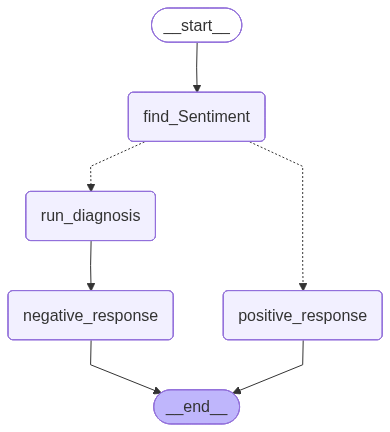

In [26]:
from IPython.display import Image
Image(Review_workflow.get_graph().draw_mermaid_png())

In [27]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
Review_workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Issue\n\nHi [User's Name],\n\nI sincerely apologize for the frustration you're experiencing with the bug issue. I understand how important it is for you to resolve this quickly, and I’m here to assist you in any way I can.\n\nCould you please provide me with a few details about the issue? Specifically, it would be helpful to know the following:\n- A brief description of the bug you're encountering\n- Steps to reproduce the issue, if possible\n- Any error messages you may have received\n\nOnce I have this information, I’ll be able to investigate further and work toward a solution for you as qu